# Testing our equation to La Jara data 

In [11]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error
import itertools

### Model Functions

In [12]:
def evolve_tauc_tc(
    tau_star,           # array of Shields stress τ*(t)
    dt,                 # timestep between τ* samples
    tau_c_min,          # minimum τ*c global
    tau_c_max,          # maximum τ*c global
    event_indices,      # time labels or integer positions where τ*c observations are available
    tau_c_obs,          # observed τ*c values at event_indices
    multiplicative_factor=1, # factor to adjust k values (e.g., for sensitivity testing)
    A=0.2924,
    B=8.6866
):

    # convert τ* to numeric 1D array and keep index if Series
    if isinstance(tau_star, pd.Series):
        tau_index = tau_star.index
        tau_star_vals = tau_star.to_numpy(dtype=float)
    else:
        tau_index = None
        tau_star_vals = np.asarray(tau_star, dtype=float)

    if tau_star_vals.ndim != 1:
        raise ValueError("tau_star must be 1D after conversion")

    # convert event indices to integer positions in tau_star_vals
    event_labels = np.asarray(event_indices)
    if tau_index is not None:
        event_pos = tau_index.get_indexer(event_labels)

        # allow an initialization observation before forcing starts (e.g., event 0 while tau index starts at 1)
        missing_mask = event_pos < 0
        if np.any(missing_mask) and np.issubdtype(event_labels.dtype, np.number):
            before_start = missing_mask & (event_labels < tau_index.min())
            event_pos[before_start] = 0

        if np.any(event_pos < 0):
            missing_labels = event_labels[event_pos < 0]
            raise ValueError(f"some event indices are not in tau_star index: {missing_labels}")
    else:
        event_pos = np.asarray(event_indices, dtype=int)

    # keep only observed τ*c values that are not NaN
    tau_c_obs_arr = np.asarray(tau_c_obs, dtype=float)
    valid_obs_mask = ~np.isnan(tau_c_obs_arr)
    event_pos_valid = event_pos[valid_obs_mask]
    tau_c_obs_valid = tau_c_obs_arr[valid_obs_mask]

    # initialize modeled τ*c, τ*c_eq, and k array
    n = len(tau_star_vals)
    tau_c = np.full(n, np.nan, dtype=float)  # nan means τ*c is undefined (e.g., during gaps)
    tau_c_pot = np.full(n, np.nan, dtype=float)
    k_array = np.full(n, np.nan, dtype=float)
    tauc_ratio = np.full(n, np.nan, dtype=float)
    tau_conv_array = np.full(n, np.nan, dtype=float)

    tau_c_obs_dict = dict(zip(event_pos_valid, tau_c_obs_valid))
    was_in_gap = True

    i = 0
    while i < n-1:
        # determine current τ*
        t = tau_star_vals[i]  # current τ*

        # k equation parameters from flume data
        k = A * (t / tau_c_max) ** B

        # initialize τ*c when observation exists
        if was_in_gap and i in tau_c_obs_dict:
            tau_c_current = tau_c_obs_dict[i]
            tau_c[i] = tau_c_current
            was_in_gap = False
        else:
            tau_c_current = tau_c[i]

        # calculate transport capacity 
        tc = t/tau_c_current  # transport capacity
        tauc_ratio[i] = tc

        # calculate potential τ*c based on current τ*/τ*c
        ks = 50
        xs = 0.79
        kw = 3.7
        if tc <= 1:
            tau_conv = tau_c_min + (tau_c_max - tau_c_min) / (1 + np.exp(-ks * (tc - xs)))
            tau_pot = max(tau_c_current, tau_conv)  # τ*c cannot decrease below current value if τ* is low
            tau_pot_pure = tau_conv
        else:  # otherwise, equilibrium is given by the weakening function
            tau_conv = tau_c_min + (tau_c_max - tau_c_min) * (tc) ** (-kw)
            tau_pot = tau_conv
            tau_pot_pure = tau_conv

        k_array[i] = k
        tau_c_pot[i] = tau_pot_pure
        tau_conv_array[i] = tau_pot

        # evolve τ*c with new equation
        tau_c[i+1] = tau_conv_array[i] - (tau_conv_array[i] - tau_c[i]) * np.exp(-k * multiplicative_factor * dt)
        #print('tauc at time:', i, 'is', tau_c[i], '. tau/tauc', tauc_ratio[i], 'and tau_pot is', tau_c_pot[i], 'with k', k_array[i])
        i += 1

    return tau_c, k_array, tau_c_pot, tauc_ratio

parameter calibration 

In [ ]:
def calibrate_parameters(
    tau_star,
    event_indices,      # indices of event start times
    tau_c_obs,          # observed τ*c at events
    dt,
    tau_c_max,
    tau_c_min_vals,
    A_vals,             # candidate values for parameter A
    B_vals,             # candidate values for parameter B
):
    
    """
    Grid-search calibration of the model using mean absolute error (MAE).
    """
    results = []
    tau_c_obs_arr = np.asarray(tau_c_obs, dtype=float)
    
    # iterate through minimum τ*c values, and A and B parameters
    for tc_idx, tau_c_min in enumerate(tau_c_min_vals):
        print(f"Testing tau_c_min = {tau_c_min:.6e} ({tc_idx + 1}/{len(tau_c_min_vals)})")
        for a_idx, A in enumerate(A_vals):
            print(f"Testing A = {A:.6e} ({a_idx + 1}/{len(A_vals)})")
            for b_idx, B in enumerate(B_vals):
                print(f"Testing B = {B:.6e} ({b_idx + 1}/{len(B_vals)})")
                tau_c_model, *_ = evolve_tauc_tc(
                    tau_star=tau_star,
                    dt=dt,
                    tau_c_min=tau_c_min,
                    tau_c_max=tau_c_max,
                    event_indices=event_indices,
                    tau_c_obs=tau_c_obs,
                    A=A,
                    B=B,
                )

                # extract modeled τ*c at event starts
                if isinstance(tau_star, pd.Series):
                    tau_c_series = pd.Series(tau_c_model, index=tau_star.index)
                    tau_c_pred = tau_c_series.reindex(event_indices).to_numpy(dtype=float)
                else:
                    event_pos = np.asarray(event_indices, dtype=int)
                    tau_c_pred = np.asarray(tau_c_model, dtype=float)[event_pos]

                # calculate mean absolute error (paper uses MAE), and ignore NaNs
                mae = np.nanmean(np.abs(tau_c_pred - tau_c_obs_arr))
                results.append({
                    "A": A,
                    "B": B,
                    "tau_c_min": tau_c_min,
                    "MAE": mae
                })

    expected = len(tau_c_min_vals) * len(A_vals) * len(B_vals)
    if len(results) != expected:
        raise RuntimeError(f"Expected {expected} calibration rows, got {len(results)}")

    return results

parameter ranges

In [36]:
# start, stop, number of values
A_vals = np.logspace(-6, 0, 150) # values evenly spaced on log scale
B_vals = np.linspace(1, 10, 35) # values from 0 to 10

### Testing Flume Data

Import Data

In [6]:
# import data 
tau_star_flume = pd.read_csv('flume_data/applied_shearstress_experiments.csv', index_col='Time')
tauc_measurements_flume = pd.read_csv('flume_data/measured_tauc.csv', index_col='Time')

4000 GPM

In [7]:
tauc_obs_4000 = tauc_measurements_flume['4000'].values
# find min and max of τ*c observations to set bounds for model
tauc_min = tauc_measurements_flume.min().min()
tauc_max = tauc_measurements_flume[-2:].mean().max()

In [ ]:
calibration = calibrate_parameters(
    tau_star_flume['4000'],
    tauc_measurements_flume.index,
    tauc_obs_4000,
    dt=1,
    tau_c_min=tauc_min,
    tau_c_max=tauc_max,
    A_vals=A_vals,
    B_vals=B_vals,
    tau_ref='max'
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing A = 1.000000e-06 (1/150)
Testing B = 1.000000e+00 (1/35)
Testing B = 1.264706e+00 (2/35)
Testing B = 1.529412e+00 (3/35)
Testing B = 1.794118e+00 (4/35)
Testing B = 2.058824e+00 (5/35)
Testing B = 2.323529e+00 (6/35)
Testing B = 2.588235e+00 (7/35)
Testing B = 2.852941e+00 (8/35)
Testing B = 3.117647e+00 (9/35)
Testing B = 3.382353e+00 (10/35)
Testing B = 3.647059e+00 (11/35)
Testing B = 3.911765e+00 (12/35)
Testing B = 4.176471e+00 (13/35)
Testing B = 4.441176e+00 (14/35)
Testing B = 4.705882e+00 (15/35)
Testing B = 4.970588e+00 (16/35)
Testing B = 5.235294e+00 (17/35)
Testing B = 5.500000e+00 (18/35)
Testing B = 5.764706e+00 (19/35)
Testing B = 6.029412e+00 (20/35)
Testing B = 6.294118e+00 (21/35)
Testing B = 6.558824e+00 (22/35)
Testing B = 6.823529e+00 (23/35)
Testing B = 7.088235e+00 (24/35)
Testing B = 7.352941e+00 (25/35)
Testing B = 7.617647e+00 (26/35)
Testing B = 7.882353e+00 (27/35)
Testing B = 8.147059e+00 (28/35)
Testing B = 8.411765e+00 (29/35)
Testing B = 8.67647

In [ ]:
tauc_flume_4000, k_flume_4000, tau_eq_flume_4000, gd = evolve_tauc(
    tau_star_flume['4000'],
    dt=1,
    tau_c_min=tauc_min,
    tau_c_max=tauc_max,
    event_indices=tauc_measurements_flume.index,    
    tau_c_obs=tauc_obs_4000,
    A=best["A"],        
    B=best["B"],
)

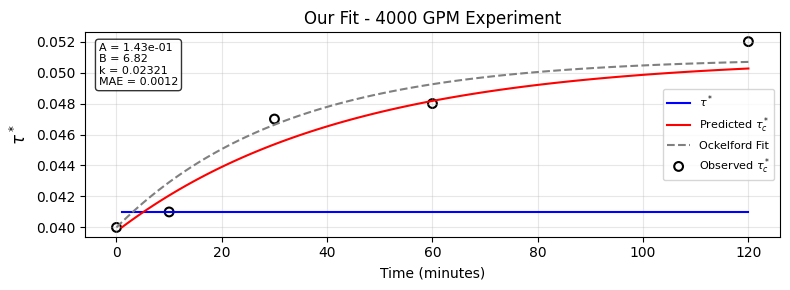

In [151]:
# tau_star is a pd.Series with datetime index
tau_c_pred_series = pd.Series(tauc_flume_4000, index=tau_star_flume.index)
tau_star_series = pd.Series(tau_star_flume['4000'].values, index=tau_star_flume.index)
obs_tauc_series = pd.Series(tauc_obs_4000, index=tauc_measurements_flume.index)
# ockelford fit 
tt = np.linspace(0,120,120)
ockelford_tauc = tau_eq_flume_4000 - (tau_eq_flume_4000 - tauc_min) * np.exp(-0.031 * tt)

fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tt, ockelford_tauc, color='gray', linestyle='--', label="Ockelford Fit", linewidth=1.5)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=40, 
        linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time (minutes)', fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.text(0.02, 0.95, f"A = {best['A']:.2e}\nB = {best['B']:.2f}\nk = {k_flume_4000:.5f}\nMAE = {best['MAE']:.4f}", 
        transform=ax.transAxes, fontsize=8, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.title('Our Fit - 4000 GPM Experiment', fontsize=12)
plt.tight_layout()
plt.show()

5000 GPM

In [152]:
tauc_obs_5000 = tauc_measurements_flume['5000'].values

calibration = calibrate_parameters(
    tau_star_flume['5000'],
    tauc_measurements_flume.index,
    tauc_obs_5000,
    dt=1,
    tau_c_min=tauc_min,
    tau_c_max=tauc_max,
    A_vals=A_vals,
    B_vals=B_vals,
    tau_ref='max'
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing A = 1.000000e-06 (1/150)
Testing B = 1.000000e+00 (1/35)
Testing B = 1.264706e+00 (2/35)
Testing B = 1.529412e+00 (3/35)
Testing B = 1.794118e+00 (4/35)
Testing B = 2.058824e+00 (5/35)
Testing B = 2.323529e+00 (6/35)
Testing B = 2.588235e+00 (7/35)
Testing B = 2.852941e+00 (8/35)
Testing B = 3.117647e+00 (9/35)
Testing B = 3.382353e+00 (10/35)
Testing B = 3.647059e+00 (11/35)
Testing B = 3.911765e+00 (12/35)
Testing B = 4.176471e+00 (13/35)
Testing B = 4.441176e+00 (14/35)
Testing B = 4.705882e+00 (15/35)
Testing B = 4.970588e+00 (16/35)
Testing B = 5.235294e+00 (17/35)
Testing B = 5.500000e+00 (18/35)
Testing B = 5.764706e+00 (19/35)
Testing B = 6.029412e+00 (20/35)
Testing B = 6.294118e+00 (21/35)
Testing B = 6.558824e+00 (22/35)
Testing B = 6.823529e+00 (23/35)
Testing B = 7.088235e+00 (24/35)
Testing B = 7.352941e+00 (25/35)
Testing B = 7.617647e+00 (26/35)
Testing B = 7.882353e+00 (27/35)
Testing B = 8.147059e+00 (28/35)
Testing B = 8.411765e+00 (29/35)
Testing B = 8.67647

In [153]:
tauc_flume_5000, k_flume_5000, tau_eq_flume_5000, gd = evolve_tauc_max(
    tau_star_flume['5000'],
    dt=1,
    tau_c_min=tauc_min,
    tau_c_max=tauc_max,
    event_indices=tauc_measurements_flume.index,    
    tau_c_obs=tauc_obs_5000,
    A=best["A"],        
    B=best["B"],
)

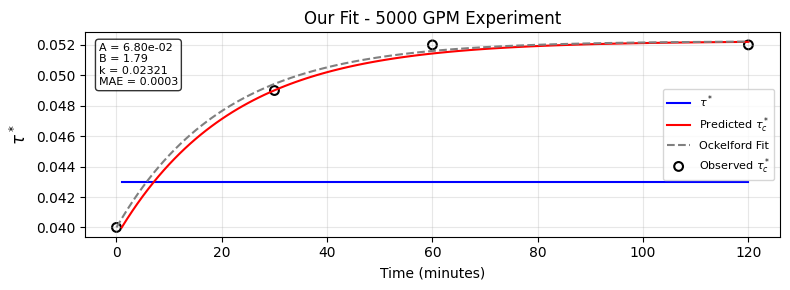

In [154]:
# tau_star is a pd.Series with datetime index
tau_c_pred_series = pd.Series(tauc_flume_5000, index=tau_star_flume.index)
tau_star_series = pd.Series(tau_star_flume['5000'].values, index=tau_star_flume.index)
obs_tauc_series = pd.Series(tauc_obs_5000, index=tauc_measurements_flume.index)
# ockelford fit 
tt = np.linspace(0,120,120)
ockelford_tauc = tau_eq_flume_5000 - (tau_eq_flume_5000 - tauc_min) * np.exp(-0.049 * tt)

fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tt, ockelford_tauc, color='gray', linestyle='--', label="Ockelford Fit", linewidth=1.5)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=40, 
        linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time (minutes)', fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.text(0.02, 0.95, f"A = {best['A']:.2e}\nB = {best['B']:.2f}\nk = {k_flume_4000:.5f}\nMAE = {best['MAE']:.4f}", 
        transform=ax.transAxes, fontsize=8, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.title('Our Fit - 5000 GPM Experiment', fontsize=12)
plt.tight_layout()
plt.show()

6000 GPM 

In [155]:
tauc_obs_6000 = tauc_measurements_flume['6000'].values

calibration = calibrate_parameters(
    tau_star_flume['6000'],
    tauc_measurements_flume.index,
    tauc_obs_6000,
    dt=1,
    tau_c_min=tauc_min,
    tau_c_max=tauc_max,
    A_vals=A_vals,
    B_vals=B_vals,
    tau_ref='max'
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing A = 1.000000e-06 (1/150)
Testing B = 1.000000e+00 (1/35)
Testing B = 1.264706e+00 (2/35)
Testing B = 1.529412e+00 (3/35)
Testing B = 1.794118e+00 (4/35)
Testing B = 2.058824e+00 (5/35)
Testing B = 2.323529e+00 (6/35)
Testing B = 2.588235e+00 (7/35)
Testing B = 2.852941e+00 (8/35)
Testing B = 3.117647e+00 (9/35)
Testing B = 3.382353e+00 (10/35)
Testing B = 3.647059e+00 (11/35)
Testing B = 3.911765e+00 (12/35)
Testing B = 4.176471e+00 (13/35)
Testing B = 4.441176e+00 (14/35)
Testing B = 4.705882e+00 (15/35)
Testing B = 4.970588e+00 (16/35)
Testing B = 5.235294e+00 (17/35)
Testing B = 5.500000e+00 (18/35)
Testing B = 5.764706e+00 (19/35)
Testing B = 6.029412e+00 (20/35)
Testing B = 6.294118e+00 (21/35)
Testing B = 6.558824e+00 (22/35)
Testing B = 6.823529e+00 (23/35)
Testing B = 7.088235e+00 (24/35)
Testing B = 7.352941e+00 (25/35)
Testing B = 7.617647e+00 (26/35)
Testing B = 7.882353e+00 (27/35)
Testing B = 8.147059e+00 (28/35)
Testing B = 8.411765e+00 (29/35)
Testing B = 8.67647

In [156]:
tauc_flume_6000, k_flume_6000, tau_eq_flume_6000, gd = evolve_tauc_max(
    tau_star_flume['6000'],
    dt=1,
    tau_c_min=tauc_min,
    tau_c_max=tauc_max,
    event_indices=tauc_measurements_flume.index,    
    tau_c_obs=tauc_obs_6000,
    A=best["A"],        
    B=best["B"],
)

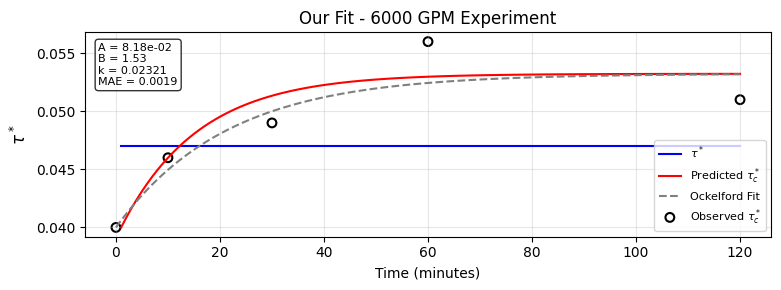

In [157]:
# tau_star is a pd.Series with datetime index
tau_c_pred_series = pd.Series(tauc_flume_6000, index=tau_star_flume.index)
tau_star_series = pd.Series(tau_star_flume['6000'].values, index=tau_star_flume.index)
obs_tauc_series = pd.Series(tauc_obs_6000, index=tauc_measurements_flume.index)
# ockelford fit 
tt = np.linspace(0,120,120)
ockelford_tauc = tau_eq_flume_6000 - (tau_eq_flume_6000 - tauc_min) * np.exp(-0.047 * tt)

fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tt, ockelford_tauc, color='gray', linestyle='--', label="Ockelford Fit", linewidth=1.5)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=40, 
        linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time (minutes)', fontsize=10)
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, alpha=0.3)
ax.text(0.02, 0.95, f"A = {best['A']:.2e}\nB = {best['B']:.2f}\nk = {k_flume_4000:.5f}\nMAE = {best['MAE']:.4f}", 
        transform=ax.transAxes, fontsize=8, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.title('Our Fit - 6000 GPM Experiment', fontsize=12)
plt.tight_layout()
plt.show()

7000 GPM 

In [158]:
tauc_obs_7000 = tauc_measurements_flume['7000'].values

calibration = calibrate_parameters(
    tau_star_flume['7000'],
    tauc_measurements_flume.index,
    tauc_obs_7000,
    dt=1,
    tau_c_min=tauc_min,
    tau_c_max=tauc_max,
    A_vals=A_vals,
    B_vals=B_vals,
    tau_ref='max'
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing A = 1.000000e-06 (1/150)
Testing B = 1.000000e+00 (1/35)
Testing B = 1.264706e+00 (2/35)
Testing B = 1.529412e+00 (3/35)
Testing B = 1.794118e+00 (4/35)
Testing B = 2.058824e+00 (5/35)
Testing B = 2.323529e+00 (6/35)
Testing B = 2.588235e+00 (7/35)
Testing B = 2.852941e+00 (8/35)
Testing B = 3.117647e+00 (9/35)
Testing B = 3.382353e+00 (10/35)
Testing B = 3.647059e+00 (11/35)
Testing B = 3.911765e+00 (12/35)
Testing B = 4.176471e+00 (13/35)
Testing B = 4.441176e+00 (14/35)
Testing B = 4.705882e+00 (15/35)
Testing B = 4.970588e+00 (16/35)
Testing B = 5.235294e+00 (17/35)
Testing B = 5.500000e+00 (18/35)
Testing B = 5.764706e+00 (19/35)
Testing B = 6.029412e+00 (20/35)
Testing B = 6.294118e+00 (21/35)
Testing B = 6.558824e+00 (22/35)
Testing B = 6.823529e+00 (23/35)
Testing B = 7.088235e+00 (24/35)
Testing B = 7.352941e+00 (25/35)
Testing B = 7.617647e+00 (26/35)
Testing B = 7.882353e+00 (27/35)
Testing B = 8.147059e+00 (28/35)
Testing B = 8.411765e+00 (29/35)
Testing B = 8.67647

In [159]:
tauc_flume_7000, k_flume_7000, tau_eq_flume_7000, gd = evolve_tauc_max(
    tau_star_flume['7000'],
    dt=1,
    tau_c_min=tauc_min,
    tau_c_max=tauc_max,
    event_indices=tauc_measurements_flume.index,    
    tau_c_obs=tauc_obs_7000,
    A=best["A"],        
    B=best["B"],
)

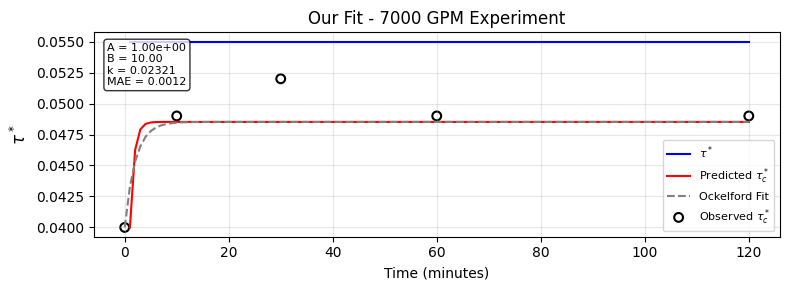

In [160]:
# tau_star is a pd.Series with datetime index
tau_c_pred_series = pd.Series(tauc_flume_7000, index=tau_star_flume.index)
tau_star_series = pd.Series(tau_star_flume['7000'].values, index=tau_star_flume.index)
obs_tauc_series = pd.Series(tauc_obs_7000, index=tauc_measurements_flume.index)
# ockelford fit 
tt = np.linspace(0,120,120)
ockelford_tauc = tau_eq_flume_7000 - (tau_eq_flume_7000 - tauc_min) * np.exp(-0.488 * tt)

fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tt, ockelford_tauc, color='gray', linestyle='--', label="Ockelford Fit", linewidth=1.5)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=40, 
        linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time (minutes)', fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.text(0.02, 0.95, f"A = {best['A']:.2e}\nB = {best['B']:.2f}\nk = {k_flume_4000:.5f}\nMAE = {best['MAE']:.4f}", 
        transform=ax.transAxes, fontsize=8, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.title('Our Fit - 7000 GPM Experiment', fontsize=12)
plt.tight_layout()
plt.show()

#### Plot All Together

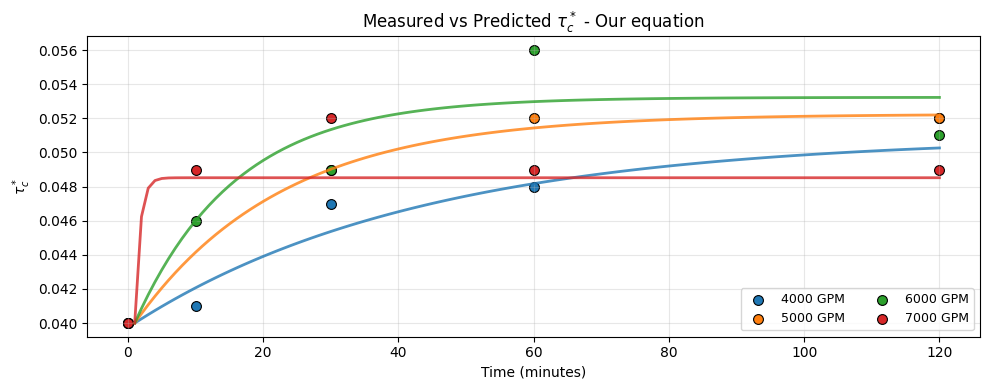

In [161]:
from ast import If


flows = ['4000', '5000', '6000', '7000']
colors = dict(zip(flows, plt.cm.tab10.colors[:4]))

# predicted tau_c* arrays from your evolve_tauc runs
pred_by_flow = {
    '4000': tauc_flume_4000,
    '5000': tauc_flume_5000,
    '6000': tauc_flume_6000,
    '7000': tauc_flume_7000,
}

fig, ax = plt.subplots(figsize=(10, 4))

for flow in flows:
    pred = pred_by_flow.get(flow, None)
    if pred is None:
        continue

    c = colors[flow]

    # time axis from flume tau* table
    time_pred = tau_star_flume.index.to_numpy()
    pred = np.asarray(pred, dtype=float)

    # safety trim in case lengths differ
    n = min(len(time_pred), len(pred))
    ax.plot(
        time_pred[:n],
        pred[:n],
        color=c,
        linewidth=2,
        alpha=0.8
    )

    # observed tau_c* for same flow
    obs_series = tauc_measurements_flume[flow].astype(float)
    valid_obs = ~obs_series.isna()

    ax.scatter(
            obs_series.index[valid_obs],
            obs_series[valid_obs],
            color=c,
            s=50,
            edgecolors='black',
            linewidth=0.8,
            label=f'{flow} GPM'
        )

ax.set_xlabel('Time (minutes)')
ax.set_ylabel(r'$\tau_c^*$')
ax.set_title(r'Measured vs Predicted $\tau_c^*$ - Our equation', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(ncol=2, fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()


### Testing a single set of A and B parameters for flume

In [162]:
def calibrate_parameters_all_flows(
    tau_star,                # DataFrame with columns like ['4000','5000','6000','7000']
    tauc_measurements,       # DataFrame with observed tau_c* at event times
    flows,                   # list of flow column names
    dt,
    A_vals,                  # candidate values for parameter A
    B_vals,                  # candidate values for parameter B
    tauc_min,
    tauc_max,
    aggregation="mean_of_flows",  # "mean_of_flows" or "pooled"
    store_all_results=True,
    verbose=True,
):
    """
    Find one shared (A, B) that minimizes MAE across all selected flows.

    aggregation:
      - "mean_of_flows": each flow contributes equally (mean of per-flow MAEs)
      - "pooled": all valid points pooled together (flow with more valid points weighs more)
    """
    if aggregation not in {"mean_of_flows", "pooled"}:
        raise ValueError("aggregation must be 'mean_of_flows' or 'pooled'")

    event_indices = tauc_measurements.index
    flow_data = {}

    # Precompute valid observations for each flow
    for flow in flows:
        tau_series = tau_star[flow]
        obs_full = tauc_measurements[flow].to_numpy(dtype=float)
        valid_mask = ~np.isnan(obs_full)

        if not np.any(valid_mask):
            raise ValueError(f"Flow {flow} has no valid observations.")

        event_labels_valid = np.asarray(event_indices)[valid_mask]
        obs_valid = obs_full[valid_mask]

        flow_data[flow] = {
            "tau_series": tau_series,
            "obs_full": obs_full,
            "event_labels_valid": event_labels_valid,
            "obs_valid": obs_valid,
        }

    combos = list(itertools.product(A_vals, B_vals))
    n_total = len(combos)

    best = None
    all_rows = []

    for i, (A, B) in enumerate(combos, start=1):
        mae_by_flow = {}
        abs_err_all = []

        for flow in flows:
            fd = flow_data[flow]
            tau_c_model, *_ = evolve_tauc_max(
                tau_star=fd["tau_series"],
                dt=dt,
                tau_c_min=float(tauc_min),
                tau_c_max=float(tauc_max),
                event_indices=event_indices,
                tau_c_obs=fd["obs_full"],
                A=A,
                B=B,
            )

            pred_series = pd.Series(tau_c_model, index=fd["tau_series"].index)
            pred_valid = pred_series.reindex(fd["event_labels_valid"]).to_numpy(dtype=float)

            valid = ~np.isnan(pred_valid) & ~np.isnan(fd["obs_valid"])
            if not np.any(valid):
                mae_flow = np.inf
                abs_err = np.array([np.inf])
            else:
                abs_err = np.abs(pred_valid[valid] - fd["obs_valid"][valid])
                mae_flow = float(np.mean(abs_err))

            mae_by_flow[flow] = mae_flow
            abs_err_all.append(abs_err)

        if aggregation == "mean_of_flows":
            total_mae = float(np.mean([mae_by_flow[f] for f in flows]))
        else:
            total_mae = float(np.mean(np.concatenate(abs_err_all)))

        row = {
            "A": float(A),
            "B": float(B),
            "MAE_total": total_mae,
        }
        for flow in flows:
            row[f"MAE_{flow}"] = mae_by_flow[flow]

        if store_all_results:
            all_rows.append(row)

        if (best is None) or (total_mae < best["MAE_total"]):
            best = row.copy()

        if verbose and (i % max(1, n_total // 20) == 0 or i == n_total):
            print(f"Progress: {i}/{n_total} ({100*i/n_total:.1f}%) | best MAE={best['MAE_total']:.6f}")

    results_df = pd.DataFrame(all_rows) if store_all_results else None
    return best, results_df


def run_best_fit_all_flows(
    tau_star,
    tauc_measurements,
    flows,
    tauc_min,
    tauc_max,
    best_params,
    dt=1.0,
):
    """
    Run evolve_tauc_max for each flow using one shared best parameter set.
    Returns dict: {flow: modeled_tau_c_array}
    """
    A = float(best_params["A"])
    B = float(best_params["B"])

    event_indices = tauc_measurements.index
    preds = {}

    for flow in flows:
        obs_full = tauc_measurements[flow].to_numpy(dtype=float)
        tau_c_model, *_ = evolve_tauc_max(
            tau_star=tau_star[flow],
            dt=dt,
            tau_c_min=float(tauc_min),
            tau_c_max=float(tauc_max),
            event_indices=event_indices,
            tau_c_obs=obs_full,
            A=A,
            B=B,
        )
        preds[flow] = tau_c_model
    return preds

In [163]:
flows = ["4000", "5000", "6000", "7000"]

best_all, results_all = calibrate_parameters_all_flows(
    tau_star=tau_star_flume,
    tauc_measurements=tauc_measurements_flume,
    flows=flows,
    dt=1,
    A_vals=A_vals,
    B_vals=B_vals,
    tauc_min=tauc_min,
    tauc_max=tauc_max,        
    aggregation="mean_of_flows",      # or "pooled"
    store_all_results=True,
    verbose=True,
)

print("Best shared parameters across all flows:")
print(best_all)

Progress: 262/5250 (5.0%) | best MAE=0.009561
Progress: 524/5250 (10.0%) | best MAE=0.009560
Progress: 786/5250 (15.0%) | best MAE=0.009558
Progress: 1048/5250 (20.0%) | best MAE=0.009554
Progress: 1310/5250 (25.0%) | best MAE=0.009545
Progress: 1572/5250 (29.9%) | best MAE=0.009530
Progress: 1834/5250 (34.9%) | best MAE=0.009494
Progress: 2096/5250 (39.9%) | best MAE=0.009431
Progress: 2358/5250 (44.9%) | best MAE=0.009289
Progress: 2620/5250 (49.9%) | best MAE=0.009048
Progress: 2882/5250 (54.9%) | best MAE=0.008523
Progress: 3144/5250 (59.9%) | best MAE=0.007697
Progress: 3406/5250 (64.9%) | best MAE=0.006152
Progress: 3668/5250 (69.9%) | best MAE=0.004301
Progress: 3930/5250 (74.9%) | best MAE=0.002438
Progress: 4192/5250 (79.8%) | best MAE=0.001649
Progress: 4454/5250 (84.8%) | best MAE=0.001344
Progress: 4716/5250 (89.8%) | best MAE=0.001302
Progress: 4978/5250 (94.8%) | best MAE=0.001302
Progress: 5240/5250 (99.8%) | best MAE=0.001302
Progress: 5250/5250 (100.0%) | best MAE=0.00

### Testing Field Data

Import Data

In [37]:
# import data 
tau_star = pd.read_csv('../../shear_stress_record/average_shear_stress_lajara_full.csv')
tauc_events = pd.read_csv('field_data/tauc_events_exceedance_rising.csv', parse_dates=['datetime'], index_col='datetime')
# convert to datetime and set as index
tau_star['datetime'] = pd.to_datetime(tau_star['datetime']) 
tau_star = tau_star.set_index('datetime')
# create continuous 15-minute time index from first timestamp to last
continuous_index = pd.date_range(start=tau_star.index.min(), end=tau_star.index.max(), freq='15min')
# change column name to 'tau' for clarity
df_tau = tau_star.rename(columns={'shear_stress': 'tau'})
# delete everything before 2022-07-14 (we don't care about earlier times)
df_tau = df_tau[df_tau.index >= '2022-07-14 15:00']


print(f"Data gaps (NaNs): {df_tau['tau'].isna().sum().sum()}")
# show what dates are the data gaps
print("Data gaps (NaN indices):", df_tau[df_tau['tau'].isna()].index)

# convert tau to dimenstionless Shields stress τ*
rho_s = 2650.0  # sediment density, kg/m3
rho = 1000.0   # fluid density, kg/m3
g = 9.81       # gravitational acceleration, m/s2
d50 = 0.04364    # median grain diameter, m

df_tau['tau_star'] = df_tau['tau'] / ((rho_s - rho) * g * d50)

# build integer index mapping
time_to_index = pd.Series(
    np.arange(len(df_tau)), 
    index=df_tau.index
)
event_indices = time_to_index.loc[tauc_events.index].to_numpy() # integer indices of event times
tau_c_obs = tauc_events["tauc"].to_numpy() # observed τ*c values
tau_star = df_tau["tau_star"].to_numpy() # τ* time series array

# calculate dt in minutes (should be 15)
dt = (df_tau.index[1] - df_tau.index[0]).total_seconds() / 60
print(f"Calculated dt: {dt} minutes")

Data gaps (NaNs): 0
Data gaps (NaN indices): DatetimeIndex([], dtype='datetime64[ns]', name='datetime', freq=None)
Calculated dt: 15.0 minutes


Run Full La Jara Record

In [38]:
tauc_obs_lajara = tauc_events["tauc"].to_numpy()
# find min and max of τ*c observations 
tauc_min_lajara = tauc_obs_lajara.min() * 0.98
tauc_max_lajara = tauc_obs_lajara.max() * 1.01

#### First Iteration

In [39]:
# start, stop, number of values
A_vals = np.logspace(-6, 0, 40) # values evenly spaced on log scale
B_vals = np.linspace(1, 10, 20) # values from 1 to 10
tauc_min_vals = np.linspace(0.02, 0.08, 15)

In [40]:
calibration = calibrate_parameters(
    tau_star,
    event_indices,
    tauc_obs_lajara,
    dt=15,
    tau_c_max=tauc_max_lajara,
    tau_c_min_vals=tauc_min_vals,
    A_vals=A_vals,
    B_vals=B_vals,
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing tau_c_min = 2.000000e-02 (1/15)
Testing A = 1.000000e-06 (1/40)
Testing B = 1.000000e+00 (1/20)
Testing B = 1.473684e+00 (2/20)
Testing B = 1.947368e+00 (3/20)
Testing B = 2.421053e+00 (4/20)
Testing B = 2.894737e+00 (5/20)
Testing B = 3.368421e+00 (6/20)
Testing B = 3.842105e+00 (7/20)
Testing B = 4.315789e+00 (8/20)
Testing B = 4.789474e+00 (9/20)
Testing B = 5.263158e+00 (10/20)
Testing B = 5.736842e+00 (11/20)
Testing B = 6.210526e+00 (12/20)
Testing B = 6.684211e+00 (13/20)
Testing B = 7.157895e+00 (14/20)
Testing B = 7.631579e+00 (15/20)
Testing B = 8.105263e+00 (16/20)
Testing B = 8.578947e+00 (17/20)
Testing B = 9.052632e+00 (18/20)
Testing B = 9.526316e+00 (19/20)
Testing B = 1.000000e+01 (20/20)
Testing A = 1.425103e-06 (2/40)
Testing B = 1.000000e+00 (1/20)
Testing B = 1.473684e+00 (2/20)
Testing B = 1.947368e+00 (3/20)
Testing B = 2.421053e+00 (4/20)
Testing B = 2.894737e+00 (5/20)
Testing B = 3.368421e+00 (6/20)
Testing B = 3.842105e+00 (7/20)
Testing B = 4.315789e

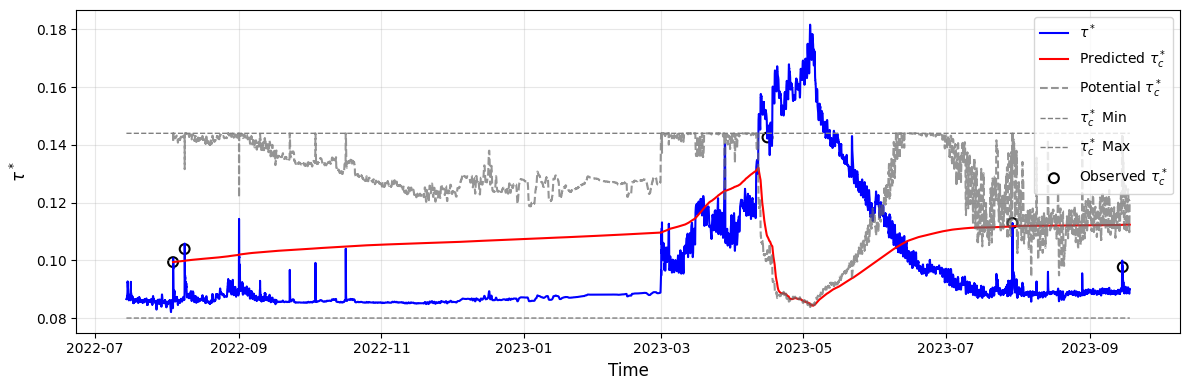

In [41]:
tauc_lajara, k_lajara, tauc_pot_lajara, tauc_ratio_lajara = evolve_tauc_tc(
    tau_star,
    dt=15, # 15 minute timestep
    tau_c_min=best["tau_c_min"],
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=best["A"],
    B=best["B"],
)

tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tauc_pot_lajara, color='dimgrey', linestyle='--', label=r'Potential $\tau_c^*$', linewidth=1.5, alpha=0.7)
# horizontal min and max lines
ax.plot(tau_c_pred_series.index, [best["tau_c_min"]]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
# plot measured tauc calibration points
obs_tauc_series = pd.Series(tauc_obs_lajara, index=tauc_events.index)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=50, linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Sensitivity Analysis

Best MAE: 0.010848
10% threshold (<=): 0.011933
Parameter sets within threshold: 5 / 600


,tau_c_min,A,B,MAE
0,0.080000,0.000203,10.0,0.010848
1,0.080000,0.000143,10.0,0.010998
2,0.080000,0.000100,10.0,0.011251
3,0.080000,0.000070,10.0,0.011581
4,0.075714,0.000143,10.0,0.011886


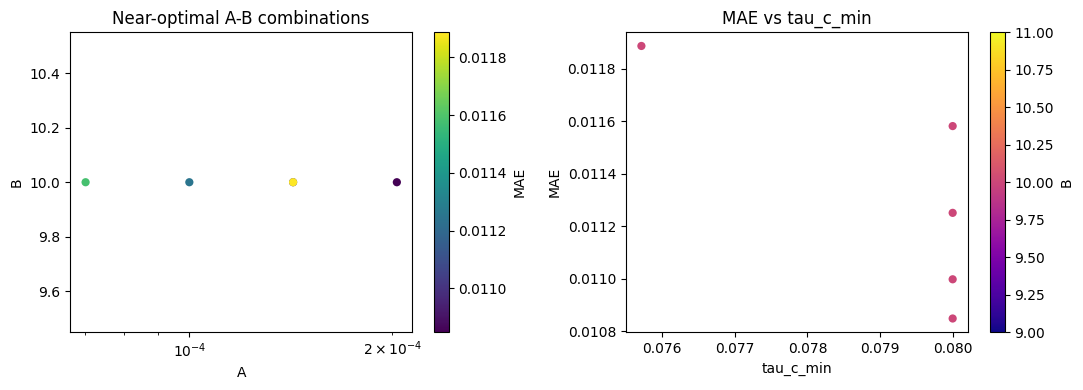

In [42]:
# sensitivity filter: keep parameter sets within 10% of the best MAE
calibration_df = pd.DataFrame(calibration)

mae_candidates = [c for c in calibration_df.columns if "mae" in c.lower()]
if not mae_candidates:
    raise ValueError(f"No MAE-like column found in calibration results. Columns: {list(calibration_df.columns)}")
mae_col = mae_candidates[0]

best_mae = calibration_df[mae_col].min()
mae_threshold = best_mae * 1.10

near_optimal = (
    calibration_df.loc[calibration_df[mae_col] <= mae_threshold]
    .sort_values(mae_col)
    .reset_index(drop=True)
)

print(f"Best MAE: {best_mae:.6f}")
print(f"10% threshold (<=): {mae_threshold:.6f}")
print(f"Parameter sets within threshold: {len(near_optimal)} / {len(calibration_df)}")

# show top candidates and all near-optimal rows.
cols_priority = [c for c in ["tau_c_min", "A", "B", mae_col] if c in near_optimal.columns]
other_cols = [c for c in near_optimal.columns if c not in cols_priority]
near_optimal = near_optimal[cols_priority + other_cols]

if len(near_optimal) > 30:
    print("\nTop 30 by MAE:")
    display(near_optimal.head(30))
else:
    display(near_optimal)

# save full near-optimal set for later analysis.
out_path = "parameter_sensitivity_analysis/1iteration_field_parameter_sets_within10pct_MAE.csv"
near_optimal.to_csv(out_path, index=False)

# quick visualization of the near-optimal parameter cloud (if expected columns exist).
if {"A", "B", "tau_c_min"}.issubset(near_optimal.columns):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sc1 = axes[0].scatter(
        near_optimal["A"],
        near_optimal["B"],
        c=near_optimal[mae_col],
        cmap="viridis",
        s=35,
        edgecolors="none",
    )
    axes[0].set_xscale("log")
    axes[0].set_xlabel("A")
    axes[0].set_ylabel("B")
    axes[0].set_title("Near-optimal A-B combinations")
    cbar1 = plt.colorbar(sc1, ax=axes[0])
    cbar1.set_label(mae_col)

    sc2 = axes[1].scatter(
        near_optimal["tau_c_min"],
        near_optimal[mae_col],
        c=near_optimal["B"],
        cmap="plasma",
        s=35,
        edgecolors="none",
    )
    axes[1].set_xlabel("tau_c_min")
    axes[1].set_ylabel(mae_col)
    axes[1].set_title("MAE vs tau_c_min")
    cbar2 = plt.colorbar(sc2, ax=axes[1])
    cbar2.set_label("B")

    plt.tight_layout()
    plt.show()

#### Second Iteration

In [31]:
# start, stop, number of values
A_vals = np.logspace(-6, 0, 40) # values evenly spaced on log scale
B_vals = np.linspace(5, 20, 10) # values from 1 to 10
tauc_min_vals = np.linspace(0.06, 0.1, 15)

In [17]:
tauc_min_vals

array([0.06      , 0.06285714, 0.06571429, 0.06857143, 0.07142857,
       0.07428571, 0.07714286, 0.08      , 0.08285714, 0.08571429,
       0.08857143, 0.09142857, 0.09428571, 0.09714286, 0.1       ])

In [32]:
B_vals

array([ 5.        ,  6.66666667,  8.33333333, 10.        , 11.66666667,
       13.33333333, 15.        , 16.66666667, 18.33333333, 20.        ])

In [20]:
A_vals

array([1.00000000e-06, 1.42510267e-06, 2.03091762e-06, 2.89426612e-06,
       4.12462638e-06, 5.87801607e-06, 8.37677640e-06, 1.19377664e-05,
       1.70125428e-05, 2.42446202e-05, 3.45510729e-05, 4.92388263e-05,
       7.01703829e-05, 1.00000000e-04, 1.42510267e-04, 2.03091762e-04,
       2.89426612e-04, 4.12462638e-04, 5.87801607e-04, 8.37677640e-04,
       1.19377664e-03, 1.70125428e-03, 2.42446202e-03, 3.45510729e-03,
       4.92388263e-03, 7.01703829e-03, 1.00000000e-02, 1.42510267e-02,
       2.03091762e-02, 2.89426612e-02, 4.12462638e-02, 5.87801607e-02,
       8.37677640e-02, 1.19377664e-01, 1.70125428e-01, 2.42446202e-01,
       3.45510729e-01, 4.92388263e-01, 7.01703829e-01, 1.00000000e+00])

In [33]:
calibration = calibrate_parameters(
    tau_star,
    event_indices,
    tauc_obs_lajara,
    dt=15,
    tau_c_max=tauc_max_lajara,
    tau_c_min_vals=tauc_min_vals,
    A_vals=A_vals,
    B_vals=B_vals,
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing tau_c_min = 6.000000e-02 (1/15)
Testing A = 1.000000e-06 (1/40)
Testing B = 5.000000e+00 (1/10)
Testing B = 6.666667e+00 (2/10)
Testing B = 8.333333e+00 (3/10)
Testing B = 1.000000e+01 (4/10)
Testing B = 1.166667e+01 (5/10)
Testing B = 1.333333e+01 (6/10)
Testing B = 1.500000e+01 (7/10)
Testing B = 1.666667e+01 (8/10)
Testing B = 1.833333e+01 (9/10)
Testing B = 2.000000e+01 (10/10)
Testing A = 1.425103e-06 (2/40)
Testing B = 5.000000e+00 (1/10)
Testing B = 6.666667e+00 (2/10)
Testing B = 8.333333e+00 (3/10)
Testing B = 1.000000e+01 (4/10)
Testing B = 1.166667e+01 (5/10)
Testing B = 1.333333e+01 (6/10)
Testing B = 1.500000e+01 (7/10)
Testing B = 1.666667e+01 (8/10)
Testing B = 1.833333e+01 (9/10)
Testing B = 2.000000e+01 (10/10)
Testing A = 2.030918e-06 (3/40)
Testing B = 5.000000e+00 (1/10)
Testing B = 6.666667e+00 (2/10)
Testing B = 8.333333e+00 (3/10)
Testing B = 1.000000e+01 (4/10)
Testing B = 1.166667e+01 (5/10)
Testing B = 1.333333e+01 (6/10)
Testing B = 1.500000e+01 (7/10

Sensitivity Analysis

Best MAE: 0.011363
10% threshold (<=): 0.012499
Parameter sets within threshold: 47 / 600

Top 30 by MAE:


,tau_c_min,A,B,MAE
0,0.094286,0.000100,20.0,0.011363
1,0.097143,0.000049,20.0,0.011529
2,0.097143,0.000070,20.0,0.011579
3,0.094286,0.000070,20.0,0.011603
4,0.100000,0.000035,20.0,0.011675
5,0.091429,0.000143,20.0,0.011707
6,0.097143,0.000035,20.0,0.011788
7,0.094286,0.000049,20.0,0.011823
8,0.100000,0.000024,20.0,0.011833
9,0.091429,0.000100,20.0,0.011846


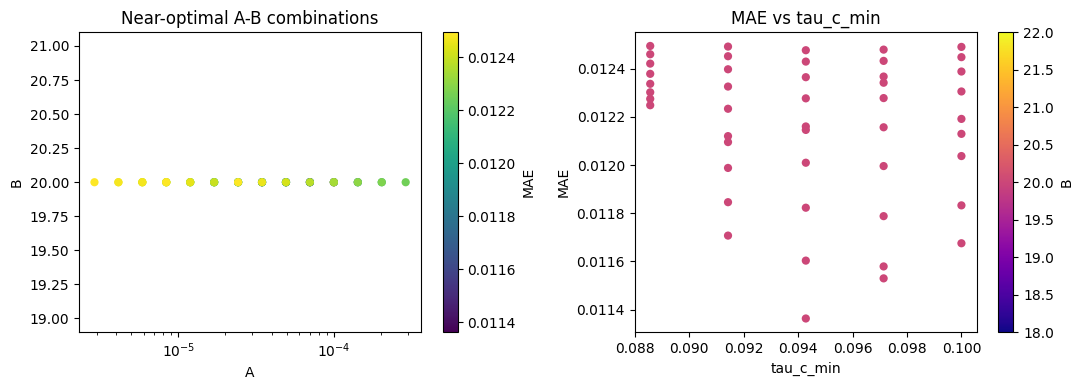

In [35]:
# sensitivity filter: keep parameter sets within 10% of the best MAE
calibration_df = pd.DataFrame(calibration)

mae_candidates = [c for c in calibration_df.columns if "mae" in c.lower()]
if not mae_candidates:
    raise ValueError(f"No MAE-like column found in calibration results. Columns: {list(calibration_df.columns)}")
mae_col = mae_candidates[0]

best_mae = calibration_df[mae_col].min()
mae_threshold = best_mae * 1.10

near_optimal = (
    calibration_df.loc[calibration_df[mae_col] <= mae_threshold]
    .sort_values(mae_col)
    .reset_index(drop=True)
)

print(f"Best MAE: {best_mae:.6f}")
print(f"10% threshold (<=): {mae_threshold:.6f}")
print(f"Parameter sets within threshold: {len(near_optimal)} / {len(calibration_df)}")

# show top candidates and all near-optimal rows.
cols_priority = [c for c in ["tau_c_min", "A", "B", mae_col] if c in near_optimal.columns]
other_cols = [c for c in near_optimal.columns if c not in cols_priority]
near_optimal = near_optimal[cols_priority + other_cols]

if len(near_optimal) > 30:
    print("\nTop 30 by MAE:")
    display(near_optimal.head(30))
else:
    display(near_optimal)

# save full near-optimal set for later analysis.
out_path = "parameter_sensitivity_analysis/2iteration_field_parameter_sets_within10pct_MAE.csv"
near_optimal.to_csv(out_path, index=False)

# quick visualization of the near-optimal parameter cloud (if expected columns exist).
if {"A", "B", "tau_c_min"}.issubset(near_optimal.columns):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sc1 = axes[0].scatter(
        near_optimal["A"],
        near_optimal["B"],
        c=near_optimal[mae_col],
        cmap="viridis",
        s=35,
        edgecolors="none",
    )
    axes[0].set_xscale("log")
    axes[0].set_xlabel("A")
    axes[0].set_ylabel("B")
    axes[0].set_title("Near-optimal A-B combinations")
    cbar1 = plt.colorbar(sc1, ax=axes[0])
    cbar1.set_label(mae_col)

    sc2 = axes[1].scatter(
        near_optimal["tau_c_min"],
        near_optimal[mae_col],
        c=near_optimal["B"],
        cmap="plasma",
        s=35,
        edgecolors="none",
    )
    axes[1].set_xlabel("tau_c_min")
    axes[1].set_ylabel(mae_col)
    axes[1].set_title("MAE vs tau_c_min")
    cbar2 = plt.colorbar(sc2, ax=axes[1])
    cbar2.set_label("B")

    plt.tight_layout()
    plt.show()